# Customer Segmentation using K-Means Clustering

## 1. Project Overview

Customer segmentation is one of the most common applications of unsupervised Machine Learning branch. Instead of predicting a target variable, clustering algorithms identify groups of customers that share similar characteristics.

From a business perspective, understanding customer segments allows companies to design more personalized marketing strategies, improve customer retention, optimize advertising campaigns, and allocate resources more efficiently.


## 2. Project Objectives
The main objective of this project is to identify meaningful customer segments using the K-Means clustering algorithm and translate the resulting clusters into actionable business insights.

General objectives of this project includes:

* Explore and understand customer demographic and purchasing behavior.
* Prepare the dataset for clustering.
* Determine an appropriate number of customer segments.
* Build a K-Means clustering model.
* Interpret each cluster from a business perspective.
* Provide marketing recommendations based on the identified customer groups.

## 3. Dataset
The dataset used in this project is the Customer Personality Analysis dataset available on Kaggle. It contains demographic information, purchasing behavior, and marketing campaign responses for customers of a retail company.

The objective of the dataset is to identify meaningful customer groups based on their purchasing habits and personal characteristics. By understanding these customer segments, businesses can develop more effective marketing strategies, personalize promotions, and improve customer engagement.

Rather than treating every customer in the same way, customer segmentation allows companies to identify groups with similar behaviors and preferences, making marketing efforts more efficient and data-driven.

The dataset contains 2,240 customer records and 29 variables, which can be grouped into four categories:


| Category      | Description                                                       |
| ------------- | ----------------------------------------------------------------- |
| **People**    | Customer demographic and socioeconomic characteristics.           |
| **Products**  | Amount spent on each product category during the last two years.  |
| **Promotion** | Customer responses to marketing campaigns and promotional offers. |
| **Place**     | Customer purchasing channels and website activity.                |

### 3.1 People Category
| Variable       | Description              |
| -------------- | ------------------------ |
| ID             | Customer identifier      |
| Year_Birth     | Birth year               |
| Education      | Education level          |
| Marital_Status | Marital status           |
| Income         | Annual household income  |
| Kidhome        | Number of children       |
| Teenhome       | Number of teenagers      |
| Dt_Customer    | Enrollment date          |
| Recency        | Days since last purchase |
| Complain       | Complaint indicator      |

### 3.2 Products Category

| Variable         | Description           |
| ---------------- | --------------------- |
| MntWines         | Wine spending         |
| MntFruits        | Fruit spending        |
| MntMeatProducts  | Meat spending         |
| MntFishProducts  | Fish spending         |
| MntSweetProducts | Sweet spending        |
| MntGoldProds     | Gold product spending |

### 3.3 Promotion Category

| Variable          | Description               |
| ----------------- | ------------------------- |
| NumDealsPurchases | Purchases using discounts |
| AcceptedCmp1      | Accepted Campaign 1       |
| AcceptedCmp2      | Accepted Campaign 2       |
| AcceptedCmp3      | Accepted Campaign 3       |
| AcceptedCmp4      | Accepted Campaign 4       |
| AcceptedCmp5      | Accepted Campaign 5       |
| Response          | Accepted last campaign    |

### 3.4 Place Category
| Variable            | Description                  |
| ------------------- | ---------------------------- |
| NumWebPurchases     | Purchases through website    |
| NumCatalogPurchases | Purchases through catalog    |
| NumStorePurchases   | Purchases in physical stores |
| NumWebVisitsMonth   | Website visits last month    |


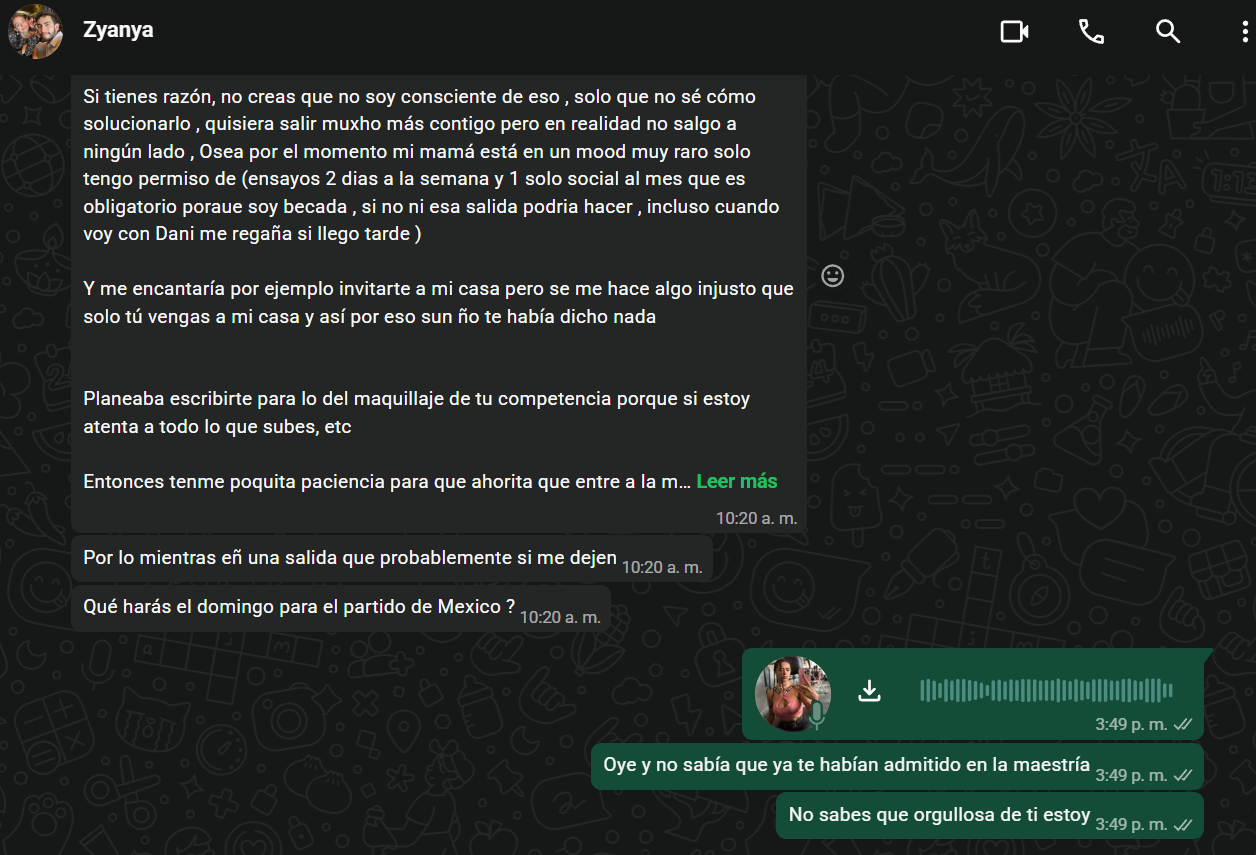

In [3]:
# Import libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme(style="whitegrid")

The following table shows the first five observations of the dataset.

In [4]:
# Load dataset
df = pd.read_csv("../data/marketing_campaign.csv", sep="\t")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## 4. Exploratory Data Analysis
It is important to understand the structure of the dataset, including the number of observations, variable types, and the presence of missing values.
### 4.1 Dataset Structure

In [5]:
# Data general info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [13]:
# Dataset dimensions
df.shape

(2240, 29)

The dataset contains 2,240 observations and 29 variables.


In [6]:
# Data types
df.dtypes

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

The dataset contains numerical variables (int64 and float64) together with three variables stored as object: Education, Marital_Status, and Dt_Customer. The latter represents enrollment dates but is currently stored as text rather than as a datetime object.

### 4.2  Numerical Variables Statistics


In [7]:
# Numerical summary
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


### 4.3 Categorical Variables Summary

In [8]:
# Categorical summary
df.describe(include='object')

,Education,Marital_Status,Dt_Customer
count,2240,2240,2240
unique,5,8,663
top,Graduation,Married,31-08-2012
freq,1127,864,12


### 4.4 Missing Values

In [9]:
# Missing values
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [10]:
missing_percentage = (
    df['Income'].isnull().mean() * 100
)

print(f"{missing_percentage:.2f}%")

1.07%


The dataset contains missing values only in the Income variable, with 24 missing observations (1.07% of the dataset). Since the proportion of missing data is very small and Income is expected to play an important role in customer segmentation, these records will be removed during the data preparation stage instead of being imputed.

### 4.5 Correlation Analysis

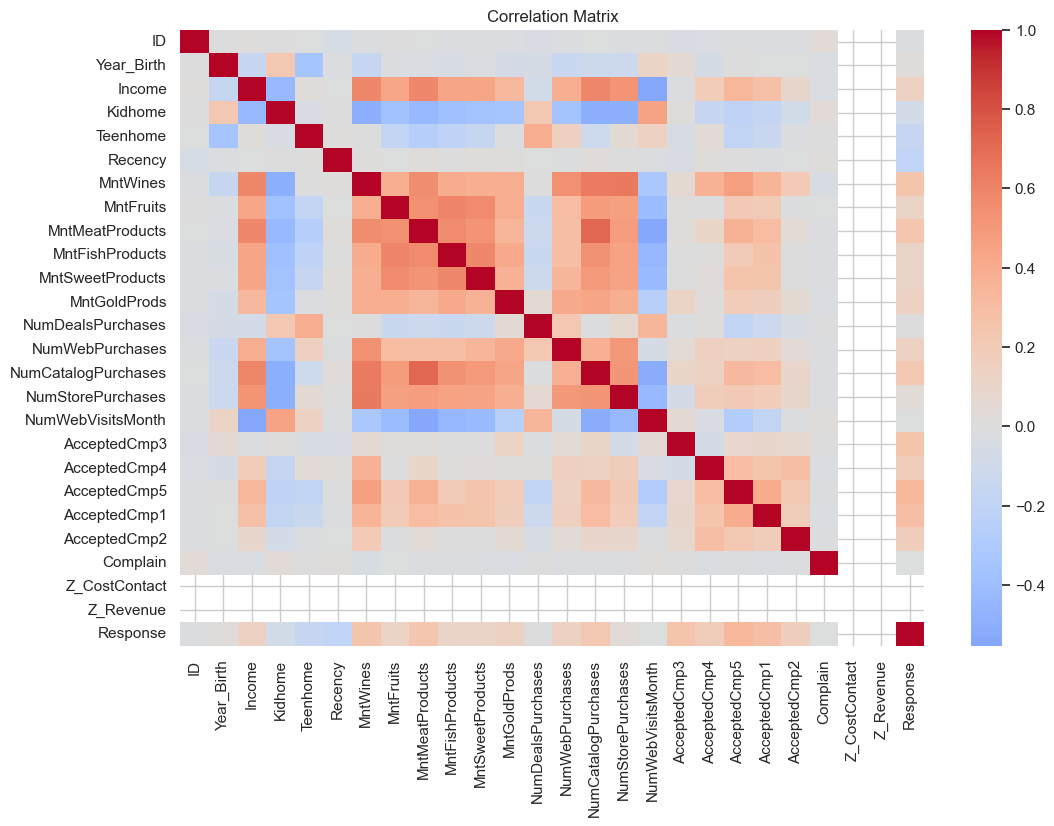

In [11]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Matrix")
plt.show()

### 4.6 Category Analysis
After analyzing the general structure, distributions, missing values, and relationships between variables, we proceed with a category-based analysis to better understand customer behavior from a business perspective.

The variables are grouped into four categories defined by the dataset: People, Products, Promotion, and Place. This approach allows us to analyze different dimensions of customer behavior before applying the clustering algorithm.
#### 4.6.1 People Analysis




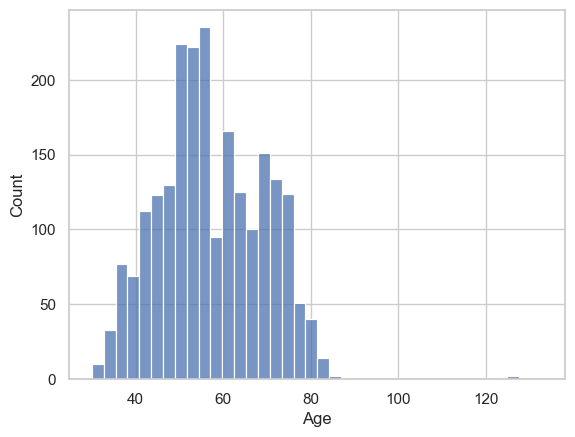

In [20]:
df["Age"] = 2026 - df["Year_Birth"]
# Plot a basic histogram
sns.histplot(data=df, x= "Age")
plt.show()

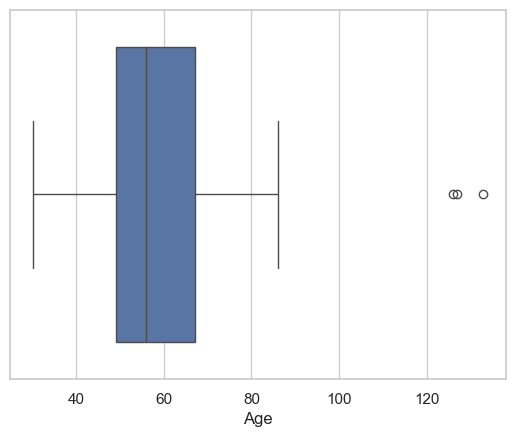

In [17]:
# Plot a basic histogram
sns.boxplot(data=df, x= "Age")
plt.show()

<Axes: xlabel='Education', ylabel='count'>

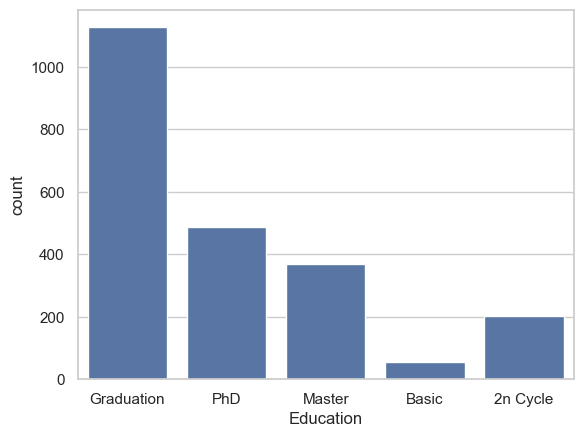

In [18]:
sns.countplot(data=df, x="Education")

<Axes: xlabel='Marital_Status', ylabel='count'>

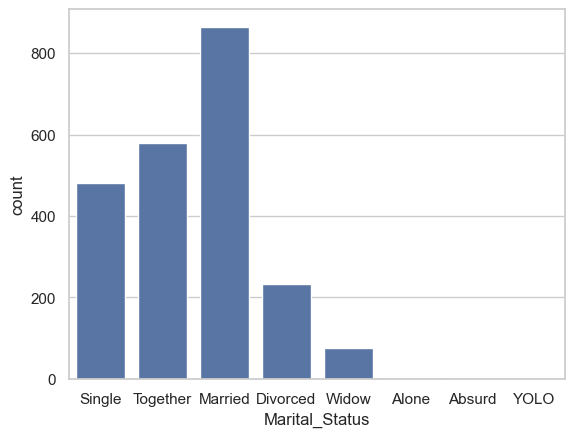

In [19]:
sns.countplot(data=df, x="Marital_Status")

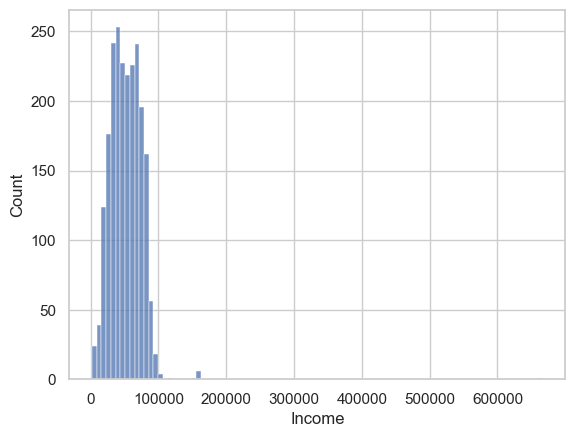

In [21]:
# Plot a basic histogram
sns.histplot(data=df, x= "Income")
plt.show()

<Axes: xlabel='Income'>

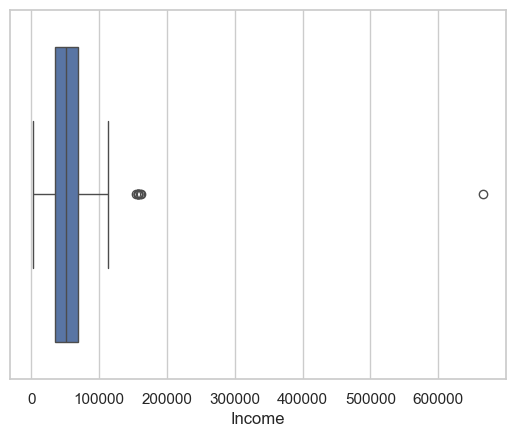

In [22]:
sns.boxplot(data=df, x="Income")

<Axes: >

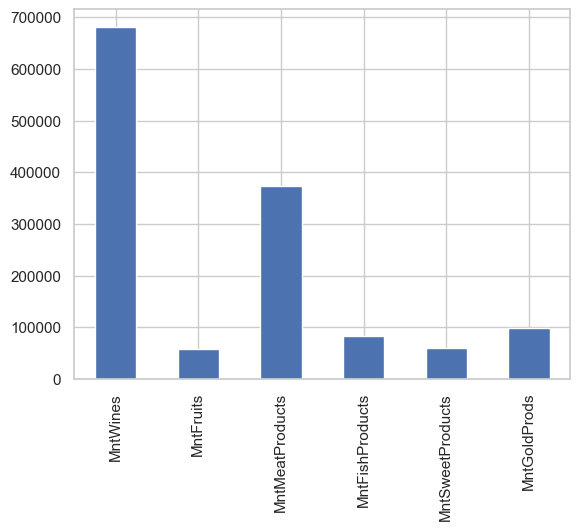

In [37]:
df[
[
"MntWines",
"MntFruits",
"MntMeatProducts",
"MntFishProducts",
"MntSweetProducts",
"MntGoldProds"
]
].sum().plot.bar()

#### 4.6.2 Products Analysis


<Axes: >

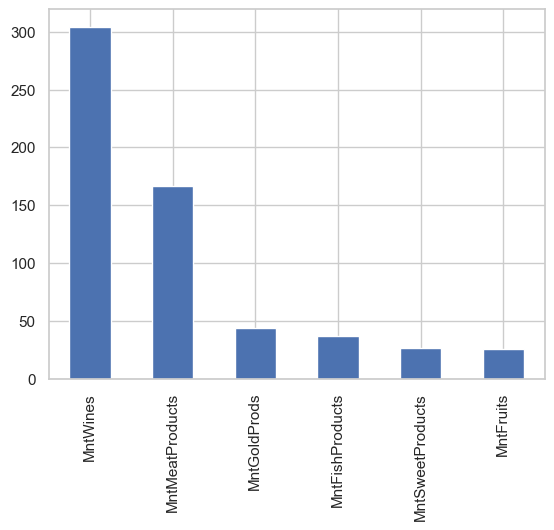

In [29]:
product_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df[product_cols].mean().sort_values(ascending=False).plot.bar()

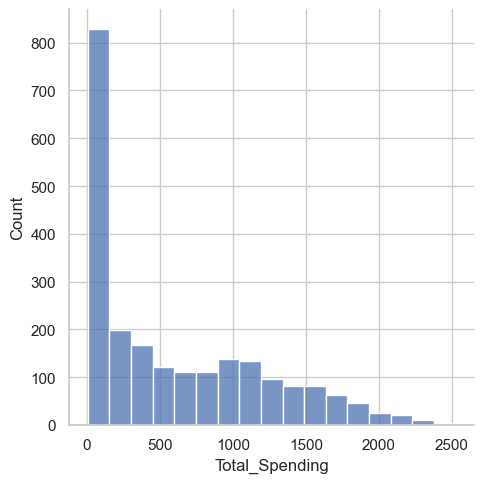

In [28]:
df["Total_Spending"] = df[product_cols].sum(axis=1)
sns.displot(data=df, x="Total_Spending")

#### 4.6.3 Promotion Analysis
#### 4.6.4 Place Analysis